In [1]:
import pandas as pd

# Load the file into a "DataFrame" (which is just Python's version of an Excel table)
df = pd.read_csv('basketball_stats.csv')

# Print the first 5 rows to make sure it worked
df.head()

,Faculty,Avg_Weekly_Practice_Hours,Total_Team_Players,Total_Team_Assists,Total_Team_Rebounds,Total_Tournament_Points
0,Engineering,15.0,15,85,120,355
1,Medicine,14.0,14,80,115,335
2,Science,12.5,13,72,98,295
3,Management,12.0,12,68,92,280
4,Technology,8.5,11,48,72,198


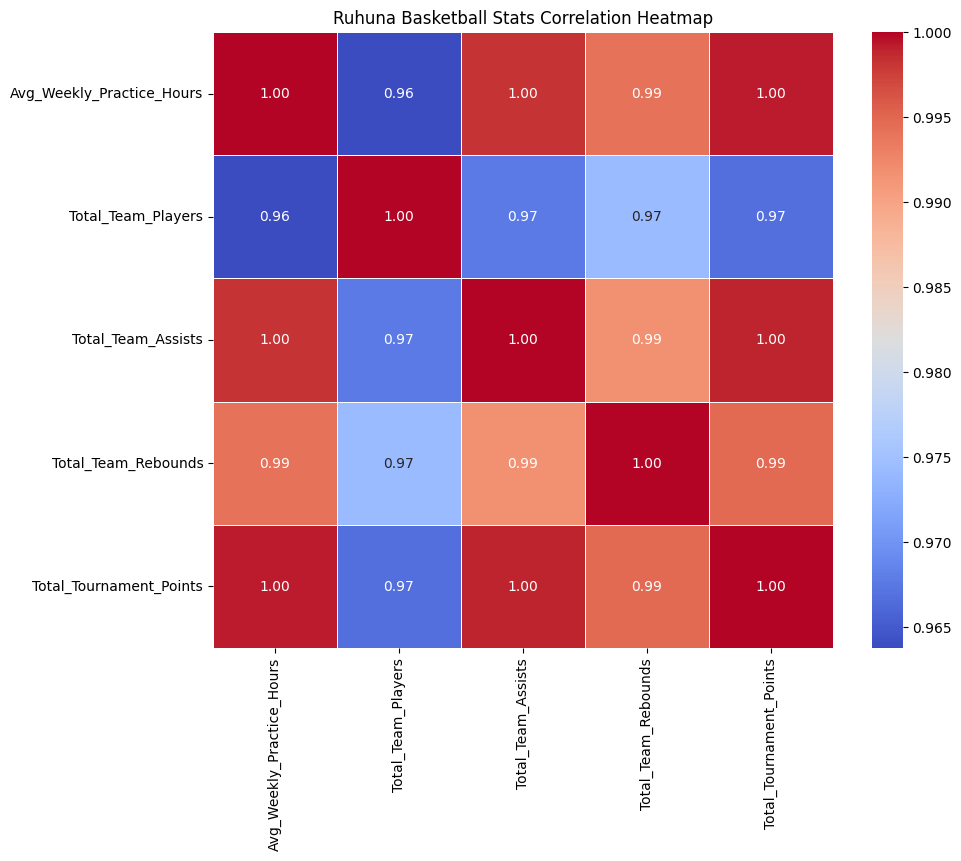

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation numbers
# We have to drop 'Faculty' because math can't calculate a word!
numeric_df = df.drop('Faculty', axis=1)
correlation_matrix = numeric_df.corr()


plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Ruhuna Basketball Stats Correlation Heatmap')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {len(X_train)} rows")
print(f"Testing data: {len(X_test)} rows")

Training data: 73 rows
Testing data: 19 rows


In [6]:
# X = The stats we use to predict (Inputs)
X = df[['Avg_Weekly_Practice_Hours', 'Total_Team_Players', 'Total_Team_Assists', 'Total_Team_Rebounds']]

# y = What we are trying to predict (Output)
y = df['Total_Tournament_Points']

print("Inputs and Outputs successfully separated!")

Inputs and Outputs successfully separated!


In [9]:
from sklearn.linear_model import LinearRegression

# 1. Create the empty model
model = LinearRegression()

# 2. Train the model using ONLY the 80% training data
model.fit(X_train, y_train)

print("Model successfully trained!")

Model successfully trained!


In [11]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. Ask the model to guess the points for the hidden test data
predictions = model.predict(X_test)

# 2. Grade the guesses
r2 = r2_score(y_test, predictions)

print(f" R-squared Score: {r2:.4f}")
print("   (1.0000 is a perfect score, 0.0000 is completely random)")

print("\n--- The AI's Learned Formula ---")
print(f"Practice Hours Weight: {model.coef_[0]:.2f}")
print(f"Team Players Weight:   {model.coef_[1]:.2f}")
print(f"Team Assists Weight:   {model.coef_[2]:.2f}")
print(f"Team Rebounds Weight:  {model.coef_[3]:.2f}")

 R-squared Score: 0.9989
   (1.0000 is a perfect score, 0.0000 is completely random)

--- The AI's Learned Formula ---
Practice Hours Weight: 9.06
Team Players Weight:   -0.72
Team Assists Weight:   1.92
Team Rebounds Weight:  0.51


In [13]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

my_team_stats = np.array([[13.5, 12, 70, 95]])

predicted_points = model.predict(my_team_stats)

print(f"Based on those stats, your team is predicted to score: {int(predicted_points[0])} points!")

Based on those stats, your team is predicted to score: 300 points!


In [14]:
import joblib
from google.colab import files

# 1. Save the model to a file named .pkl (Pickle file)
joblib.dump(model, 'ruhuna_hoops_model.pkl')

# 2. Automatically download it to your actual computer
files.download('ruhuna_hoops_model.pkl')

print("Model downloaded! The AI's brain is now on your hard drive.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model downloaded! The AI's brain is now on your hard drive.


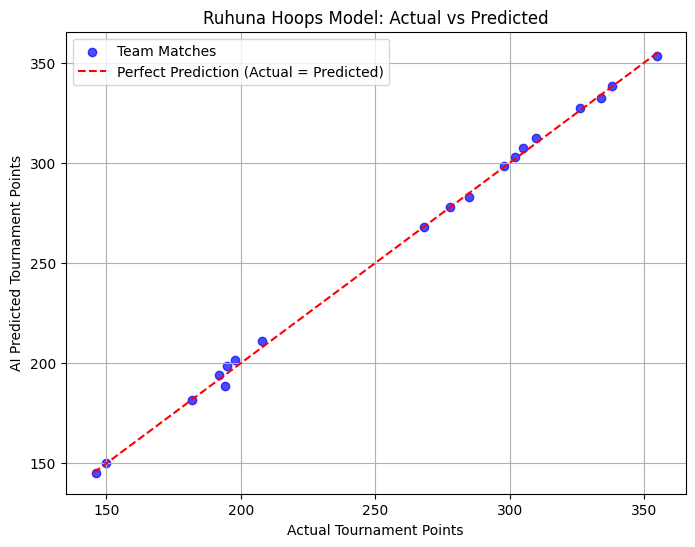

In [16]:
import matplotlib.pyplot as plt

# 1. Set the size of the graph
plt.figure(figsize=(8, 6))

# y_test is the real score, predictions is the AI's guess
plt.scatter(y_test, predictions, color='blue', alpha=0.7, label='Team Matches')

# If the AI guesses perfectly, every single dot will land exactly on this red line.
max_val = max(max(y_test), max(predictions))
min_val = min(min(y_test), min(predictions))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction (Actual = Predicted)')


plt.xlabel("Actual Tournament Points")
plt.ylabel("AI Predicted Tournament Points")
plt.title("Ruhuna Hoops Model: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np

print("--- Ruhuna Basketball AI Predictor ---")


practice_slider = widgets.FloatSlider(value=12.0, min=5.0, max=20.0, step=0.5, description='Practice Hrs:')
players_slider = widgets.IntSlider(value=12, min=5, max=15, step=1, description='Players:')
assists_slider = widgets.IntSlider(value=60, min=20, max=100, step=1, description='Assists:')
rebounds_slider = widgets.IntSlider(value=80, min=40, max=130, step=1, description='Rebounds:')

# 2. Create a Predict button and an Output area
button = widgets.Button(description="Predict Points!", button_style='success')
output = widgets.Output()

# 3. Define what happens when you click the button
def calculate_prediction(b):
    with output:
        output.clear_output()

        # Grab the current numbers from the sliders
        current_stats = np.array([[practice_slider.value, players_slider.value, assists_slider.value, rebounds_slider.value]])

        # Feed them to your trained AI model
        prediction = model.predict(current_stats)

        # Show the result!
        print(f" PREDICTED TOURNAMENT POINTS: {int(prediction[0])}")

# 4. Connect the button to the function
button.on_click(calculate_prediction)

# 5. Display the UI on the screen
display(practice_slider, players_slider, assists_slider, rebounds_slider, button, output)

--- Ruhuna Basketball AI Predictor ---


FloatSlider(value=12.0, description='Practice Hrs:', max=20.0, min=5.0, step=0.5)

IntSlider(value=12, description='Players:', max=15, min=5)

IntSlider(value=60, description='Assists:', min=20)

IntSlider(value=80, description='Rebounds:', max=130, min=40)

Button(button_style='success', description='Predict Points!', style=ButtonStyle())

Output()